# Práctica de PySpark ML: predicción de costes médicos

**Dataset:** [Insurance](https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv)  
**Variable objetivo:** `charges` (costes médicos individuales facturados)  
**Semilla de reproducibilidad:** 42

La práctica mantiene claramente separadas las dos partes del enunciado:

1. **EDA con la API de pandas de PySpark** (`pyspark.pandas`).
2. **Preparación y regresión lineal con `pyspark.ml`** sobre un DataFrame normal de Spark.

> Las transformaciones que aprenden parámetros (`StringIndexer` y `StandardScaler`) se ajustan
> únicamente con el conjunto de entrenamiento al formar parte del `Pipeline`.

## Comprobación del entorno en Google Colab

Esta celda comprueba automáticamente si PySpark está disponible. Si se ejecuta en Google Colab y PySpark no está instalado, prepara el entorno instalando **Java 17 y PySpark 3.5.1**, las versiones propuestas expresamente en el enunciado. En una ejecución local no modifica el entorno automáticamente; si detecta que falta PySpark, indica que deben consultarse `README.md` y `requirements.txt` para realizar la instalación.

In [31]:
# ==============================================================
# COMPROBACIÓN Y PREPARACIÓN DEL ENTORNO
# ==============================================================
# Esta celda puede ejecutarse tanto en Google Colab como en un
# ordenador local.
#
# Su objetivo es:
# 1. detectar si el notebook se está ejecutando en Google Colab;
# 2. comprobar si PySpark ya está instalado;
# 3. instalar Java 17 y PySpark 3.5.1 solamente cuando sean
#    necesarios dentro de Google Colab.
#
# Java 17 y PySpark 3.5.1 son las versiones propuestas
# expresamente en el enunciado de la práctica.

import importlib.util
import os
import subprocess
import sys


# --------------------------------------------------------------
# 1. Identificación del entorno
# --------------------------------------------------------------
# Google Colab carga el módulo "google.colab" automáticamente.
# Su presencia en sys.modules permite saber si el notebook
# se está ejecutando dentro de Colab.
IN_COLAB = "google.colab" in sys.modules

# find_spec() comprueba si el paquete pyspark está disponible
# sin necesidad de importarlo todavía.
PYSPARK_AVAILABLE = importlib.util.find_spec("pyspark") is not None


# --------------------------------------------------------------
# 2. Instalación automática en Google Colab
# --------------------------------------------------------------
# La instalación sólo se realiza cuando se cumplen simultáneamente
# estas dos condiciones:
# - el notebook se está ejecutando en Google Colab;
# - PySpark no está instalado.
if IN_COLAB and not PYSPARK_AVAILABLE:
    print(
        "PySpark no está instalado. "
        "Preparando Java 17 y PySpark 3.5.1..."
    )

    # Actualiza silenciosamente la información de los repositorios
    # de paquetes del sistema operativo de Colab.
    #
    # check=True hace que Python detenga la ejecución si el comando
    # finaliza con algún error.
    subprocess.run(
        ["apt-get", "update", "-qq"],
        check=True,
    )

    # Instala Java 17 sin solicitar confirmación al usuario.
    # Spark necesita una máquina virtual de Java para funcionar.
    subprocess.run(
        [
            "apt-get",
            "install",
            "-y",
            "openjdk-17-jdk-headless",
            "-qq",
        ],
        check=True,
    )

    # Instala PySpark 3.5.1 utilizando el mismo intérprete de
    # Python que está ejecutando el notebook.
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "pyspark==3.5.1",
        ],
        check=True,
    )

    # JAVA_HOME indica a PySpark dónde se encuentra Java.
    os.environ["JAVA_HOME"] = (
        "/usr/lib/jvm/java-17-openjdk-amd64"
    )

    # Se añade también la carpeta de ejecutables de Java al PATH
    # para que pueda localizarse durante esta sesión.
    os.environ["PATH"] += (
        ":/usr/lib/jvm/java-17-openjdk-amd64/bin"
    )

    print(
        "Instalación terminada. "
        "Ya se puede continuar con la siguiente celda."
    )


# --------------------------------------------------------------
# 3. PySpark ya se encuentra instalado
# --------------------------------------------------------------
# Si PySpark ya está disponible, no se reinstala ni se modifica
# su versión. Únicamente se importa y se muestra la versión
# encontrada en el entorno.
elif PYSPARK_AVAILABLE:
    import pyspark

    print(
        "PySpark ya está disponible "
        f"(versión {pyspark.__version__})."
    )


# --------------------------------------------------------------
# 4. PySpark no está instalado en un entorno local
# --------------------------------------------------------------
# Fuera de Google Colab no se realizan instalaciones automáticas,
# porque cada ordenador puede utilizar un sistema operativo y una
# configuración de Java diferentes.
#
# En ese caso, README.md y requirements.txt contienen la información
# necesaria para preparar manualmente el entorno del proyecto.
else:
    print(
        "PySpark no está instalado en el entorno local. "
        "Consulta README.md y requirements.txt para preparar "
        "las dependencias necesarias."
    )

PySpark ya está disponible (versión 4.0.4).


## Funciones auxiliares de presentación

Las siguientes funciones centralizan el formato de recuentos, porcentajes e interpretaciones. Se definen una sola vez para reutilizarlas durante toda la práctica y evitar repetir código en las diferentes secciones.

In [32]:
# ==============================================================
# FUNCIONES AUXILIARES GENERALES DE PRESENTACIÓN
# ==============================================================
# Estas funciones no realizan cálculos estadísticos ni modifican
# los datos. Sólo se encargan de presentar los resultados de forma
# homogénea durante toda la práctica.

from IPython.display import Markdown, display


def format_count(value):
    """
    Formatea un recuento entero utilizando el punto como
    separador de millares.

    Ejemplo:
    1064 -> 1.064
    """
    return f"{int(value):,}".replace(",", ".")


def format_decimal(value, decimals=2):
    """
    Formatea un número decimal utilizando la coma como
    separador decimal.

    El número de decimales puede modificarse mediante el
    argumento decimals.

    Ejemplo:
    format_decimal(49.4828, 2) -> 49,48
    """
    formatted_value = f"{float(value):,.{decimals}f}"

    return (
        formatted_value
        .replace(",", "_")
        .replace(".", ",")
        .replace("_", ".")
    )


def bold_count(value):
    """
    Formatea un recuento y lo resalta en negrita mediante Markdown.
    """
    return f"**{format_count(value)}**"


def bold_percentage(value, decimals=2):
    """
    Formatea un porcentaje y lo resalta en negrita mediante Markdown.
    """
    return f"**{format_decimal(value, decimals)} %**"


def bold_decimal(value, decimals=2):
    """
    Formatea un número decimal y lo resalta en negrita.
    """
    return f"**{format_decimal(value, decimals)}**"


def show_interpretation(text, title="Interpretación en texto"):
    """
    Presenta una interpretación como Markdown entre dos
    líneas horizontales.

    El título puede personalizarse mediante el argumento title.
    """
    display(
        Markdown(
            "---\n\n"
            f"#### {title}\n\n"
            f"{text}\n\n"
            "---"
        )
    )


def get_category_stats(table, category):
    """
    Obtiene la frecuencia y el porcentaje de una categoría
    contenidos en una tabla de distribución.

    Devuelve:
    (frecuencia, porcentaje)
    """
    frequency = int(
        table.loc[category, "frecuencia"]
    )

    percentage = float(
        table.loc[category, "porcentaje"]
    )

    return frequency, percentage

# Parte 1 (6 puntos): EDA con la API de pandas de PySpark

## 1.1. Inicio de Spark y carga reproducible

Spark no interpreta una URL HTTPS como una ruta de fichero ordinaria. Por eso se usa la copia local
`insurance.csv` y, si no existe (por ejemplo, al subir sólo el notebook a Colab), se descarga primero.
El análisis posterior sí se realiza sobre un `pyspark.pandas.DataFrame`. También se desactiva el
modo ANSI: Spark 4.x lo activa por defecto, pero algunas operaciones de pandas API de PySpark lo
rechazan para evitar diferencias de comportamiento con pandas.

In [33]:
# ==============================================================
# INICIO DE SPARK Y CARGA DEL DATASET
# ==============================================================
# Esta celda:
# 1. importa las bibliotecas necesarias;
# 2. configura e inicia una sesión de Spark;
# 3. localiza o descarga insurance.csv;
# 4. carga el dataset mediante pandas API de PySpark;
# 5. comprueba que las columnas obligatorias estén presentes;
# 6. muestra información del entorno y una primera vista de los datos.

from pathlib import Path
from urllib.request import urlretrieve
import os
import sys
import warnings


# --------------------------------------------------------------
# 1. Configuración previa a la importación de PySpark
# --------------------------------------------------------------
# Esta variable debe establecerse antes de importar pyspark.pandas.
#
# Evita una advertencia relacionada con la zona horaria cuando
# PyArrow intercambia información temporal entre Python y Spark.
# Aunque este dataset no contiene fechas, se establece para que
# el entorno sea consistente.
os.environ.setdefault(
    "PYARROW_IGNORE_TIMEZONE",
    "1",
)


# --------------------------------------------------------------
# 2. Importación de las bibliotecas
# --------------------------------------------------------------
# matplotlib se utiliza para las visualizaciones del EDA.
import matplotlib.pyplot as plt

# pandas tradicional se utiliza posteriormente para presentar
# pequeñas tablas y resultados del modelo.
import pandas as pd

# pyspark permite consultar la versión instalada.
import pyspark

# ps es la API de pandas de PySpark exigida en la primera parte
# del enunciado.
import pyspark.pandas as ps

# Esta clase permite identificar específicamente los avisos
# informativos de pandas API de PySpark.
from pyspark.pandas.utils import PandasAPIOnSparkAdviceWarning

# display y Markdown mejoran la presentación de tablas
# e interpretaciones dentro de Colab.
from IPython.display import Markdown, display

# SparkSession es el punto de entrada principal para trabajar
# con Spark desde Python.
from pyspark.sql import SparkSession


# --------------------------------------------------------------
# 3. Creación de la sesión de Spark
# --------------------------------------------------------------
spark = (
    SparkSession.builder

    # local[*] ejecuta Spark en la máquina actual y permite utilizar
    # todos los núcleos de procesamiento disponibles.
    .master("local[*]")

    # Este nombre permite identificar la aplicación en los registros
    # y herramientas de supervisión de Spark.
    .appName("Práctica PySpark ML - Insurance")

    # Spark 4.x activa el modo ANSI de forma predeterminada.
    # Algunas operaciones de pandas API de PySpark no admiten ese
    # comportamiento, por lo que se desactiva para mantener
    # compatibilidad con PySpark 3.5.1 y Spark 4.x.
    .config(
        "spark.sql.ansi.enabled",
        "false",
    )

    # Recupera una sesión existente o crea una nueva si todavía
    # no hay ninguna disponible.
    .getOrCreate()
)

# getOrCreate() puede devolver una sesión que ya existía y que
# conservaba otra configuración. Por eso se vuelve a establecer
# explícitamente el modo ANSI después de obtener la sesión.
spark.conf.set(
    "spark.sql.ansi.enabled",
    "false",
)

# Se limita la salida de Spark a advertencias y errores para evitar
# que los mensajes internos dificulten la lectura del notebook.
spark.sparkContext.setLogLevel("WARN")

# Si pandas API de PySpark necesita crear un índice automáticamente,
# se utilizará un índice distribuido. Así se evita depender de una
# secuencia global generada en un único nodo.
ps.set_option(
    "compute.default_index_type",
    "distributed",
)


# --------------------------------------------------------------
# 4. Parámetros reproducibles y ubicación del dataset
# --------------------------------------------------------------
# Esta semilla se reutilizará posteriormente en la división entre
# entrenamiento y prueba para obtener resultados reproducibles.
SEED = 42

# Dirección original del dataset indicada en el enunciado.
DATASET_URL = (
    "https://raw.githubusercontent.com/stedy/"
    "Machine-Learning-with-R-datasets/master/insurance.csv"
)

# Se buscan dos ubicaciones:
# - insurance.csv en el directorio de trabajo actual;
# - /content/insurance.csv, ubicación habitual de Google Colab.
local_candidates = [
    Path("insurance.csv"),
    Path("/content/insurance.csv"),
]

# next() devuelve la primera ruta existente.
#
# Si ninguna existe, se utiliza insurance.csv como destino
# para la descarga.
dataset_path = next(
    (
        path
        for path in local_candidates
        if path.exists()
    ),
    Path("insurance.csv"),
)

# El archivo sólo se descarga cuando no existe una copia local.
# Esto permite ejecutar la práctica sin depender siempre de una
# conexión a Internet.
if not dataset_path.exists():
    print(
        "No se encontró el CSV local; "
        "se descarga desde la fuente indicada."
    )

    urlretrieve(
        DATASET_URL,
        dataset_path,
    )


# --------------------------------------------------------------
# 5. Carga con pandas API de PySpark
# --------------------------------------------------------------
# insurance.csv no contiene una columna identificadora única.
# Por ello, no se especifica index_col y pandas API de PySpark
# crea un índice distribuido automáticamente.
#
# PySpark muestra un aviso indicando que esta operación puede añadir
# cierta sobrecarga. En este caso se trata de una decisión consciente:
# el dataset sólo contiene 1.338 registros y ninguna de sus variables
# debe utilizarse artificialmente como índice.
#
# Se oculta únicamente este aviso concreto durante la lectura.
# Cualquier otra advertencia seguirá mostrándose normalmente.
with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message=(
            r"If `index_col` is not specified for `read_csv`.*"
        ),
        category=PandasAPIOnSparkAdviceWarning,
    )

    # A partir de aquí el EDA se realiza con pandas API de PySpark,
    # no con un DataFrame de pandas tradicional.
    psdf = ps.read_csv(
        str(dataset_path.resolve())
    )


# --------------------------------------------------------------
# 6. Validación inicial de la estructura
# --------------------------------------------------------------
# Estas son las siete variables descritas en el enunciado.
expected_columns = {
    "age",
    "sex",
    "bmi",
    "children",
    "smoker",
    "region",
    "charges",
}

# Se calcula la diferencia entre las columnas obligatorias y
# las columnas realmente encontradas.
missing_columns = (
    expected_columns
    - set(psdf.columns)
)

# Si falta alguna columna, la ejecución se detiene inmediatamente.
# Entrenar el modelo con una estructura incompleta produciría
# resultados incorrectos o errores posteriores menos claros.
if missing_columns:
    raise ValueError(
        "Faltan columnas obligatorias: "
        f"{sorted(missing_columns)}"
    )


# --------------------------------------------------------------
# 7. Información del entorno y primera inspección
# --------------------------------------------------------------
print(
    f"Dataset cargado desde: {dataset_path.resolve()}"
)

print(
    f"Python: {sys.version.split()[0]} "
    f"| PySpark: {pyspark.__version__} "
    f"| Spark: {spark.version}"
)

# spark._jvm permite consultar la versión de Java utilizada
# por la máquina virtual sobre la que se ejecuta Spark.
java_version = (
    spark._jvm
    .java
    .lang
    .System
    .getProperty("java.version")
)

print(
    f"Java: {java_version} "
    f"| Modo ANSI: "
    f"{spark.conf.get('spark.sql.ansi.enabled')}"
)

# Se muestran las primeras filas para verificar visualmente
# que el archivo se ha leído de forma correcta.
display(psdf.head())

Dataset cargado desde: /content/insurance.csv
Python: 3.13.15 | PySpark: 4.0.4 | Spark: 4.0.4
Java: 21.0.11 | Modo ANSI: false


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 1.2. Estructura, tipos y calidad inicial

Se comprueban dimensiones, esquema lógico, nulos y duplicados. Un duplicado exacto puede sesgar
ligeramente el ajuste al otorgar más peso a una observación; se documenta aquí y se eliminará antes
del modelado, sin alterar el objeto usado para el EDA.
Esta celda utiliza las funciones generales bold_count() y show_interpretation(), que deben haberse definido previamente en la celda de funciones auxiliares.

In [34]:
# ==============================================================
# ESTRUCTURA, TIPOS Y CALIDAD INICIAL DEL DATASET
# ==============================================================
# En esta celda se comprueban:
# 1. el número de filas y columnas;
# 2. los tipos de datos;
# 3. los valores nulos;
# 4. las filas completamente duplicadas;
# 5. una interpretación textual de los resultados.


# --------------------------------------------------------------
# 1. Dimensiones del dataset
# --------------------------------------------------------------
# En pandas API de PySpark, consultar el número de filas requiere
# una operación distribuida porque los datos pueden encontrarse
# repartidos entre diferentes particiones.
#
# Se consulta shape una sola vez y se desempaquetan sus dos valores:
# número de filas y número de columnas.
row_count, column_count = psdf.shape

print(
    f"Dimensiones: {row_count} filas "
    f"y {column_count} columnas"
)


# --------------------------------------------------------------
# 2. Tipos de datos
# --------------------------------------------------------------
# dtypes devuelve el tipo asignado a cada columna:
# - int32: números enteros;
# - float64: números decimales;
# - object: valores de texto en pandas API de PySpark.
data_types = psdf.dtypes.rename(
    "tipo"
)

print("\nTipos de datos:")
display(data_types)


# --------------------------------------------------------------
# 3. Valores nulos por columna
# --------------------------------------------------------------
# isnull() genera una estructura de valores booleanos:
# - True cuando el valor es nulo;
# - False cuando el valor está informado.
#
# sum(axis=0) suma los valores True verticalmente y obtiene
# el número de nulos de cada columna.
#
# axis=0 se especifica expresamente para evitar el FutureWarning
# mostrado por Spark 4.x.
null_counts = (
    psdf
    .isnull()
    .sum(axis=0)
    .rename("nulos")
)

print("\nValores nulos por columna:")
display(null_counts)


# --------------------------------------------------------------
# 4. Detección de duplicados exactos
# --------------------------------------------------------------
# duplicated() conserva la primera aparición de cada registro
# y marca como duplicadas solamente las repeticiones posteriores.
#
# Por ejemplo, si una fila aparece dos veces:
# - la primera se considera el registro original;
# - la segunda se contabiliza como un duplicado.
duplicate_mask = psdf.duplicated()

duplicate_count = int(
    duplicate_mask.sum()
)

print(
    "\nFilas completamente duplicadas: "
    f"{duplicate_count}"
)


# --------------------------------------------------------------
# 5. Inspección de las filas implicadas
# --------------------------------------------------------------
# Para inspeccionar los duplicados se utiliza keep=False.
# Así se muestran tanto la primera aparición como sus copias.
#
# Por esta razón, cuando existe un único duplicado pueden mostrarse
# dos filas: el registro original y su repetición.
if duplicate_count > 0:
    all_duplicate_mask = psdf.duplicated(
        keep=False
    )

    all_duplicate_rows = (
        psdf[all_duplicate_mask]
        .sort_values(
            by=list(psdf.columns)
        )
    )

    print(
        "\nRegistros originales y copias "
        "implicados en los duplicados:"
    )

    display(all_duplicate_rows)

else:
    print(
        "\nNo se han encontrado filas completamente duplicadas."
    )


# --------------------------------------------------------------
# 6. Resumen textual de estructura y calidad
# --------------------------------------------------------------
# Se suman los nulos de todas las columnas para poder generar
# una conclusión general sobre la calidad del dataset.
total_null_count = int(
    null_counts.sum()
)

# El texto se adapta automáticamente al resultado obtenido.
if total_null_count == 0:
    null_summary = (
        "No se han detectado valores nulos en ninguna columna."
    )
elif total_null_count == 1:
    null_summary = (
        "Se ha detectado "
        f"{bold_count(total_null_count)} valor nulo."
    )
else:
    null_summary = (
        "Se han detectado "
        f"{bold_count(total_null_count)} valores nulos."
    )

# Se adapta también el texto al número de duplicados.
if duplicate_count == 0:
    duplicate_summary = (
        "Tampoco se han encontrado filas completamente duplicadas."
    )
elif duplicate_count == 1:
    duplicate_summary = (
        "Se ha detectado "
        f"{bold_count(duplicate_count)} fila completamente duplicada, "
        "que se eliminará antes de dividir los datos para el modelado."
    )
else:
    duplicate_summary = (
        "Se han detectado "
        f"{bold_count(duplicate_count)} filas completamente duplicadas, "
        "que se eliminarán antes de dividir los datos para el modelado."
    )

# Las dimensiones, los nulos y los duplicados se incorporan
# dinámicamente al texto final.
quality_summary = (
    "El dataset contiene "
    f"{bold_count(row_count)} registros y "
    f"{bold_count(column_count)} variables. "
    f"{null_summary} {duplicate_summary}"
)

# La función general presenta el texto como Markdown y permite
# mostrar las cifras dinámicas en negrita.
show_interpretation(
    quality_summary,
    title="Resumen de estructura y calidad",
)

Dimensiones: 1338 filas y 7 columnas

Tipos de datos:


,tipo
age,int32
sex,object
bmi,float64
children,int32
smoker,object
region,object
charges,float64



Valores nulos por columna:


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
Name: nulos, dtype: int64


Filas completamente duplicadas: 1

Registros originales y copias implicados en los duplicados:


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


---

#### Resumen de estructura y calidad

El dataset contiene **1.338** registros y **7** variables. No se han detectado valores nulos en ninguna columna. Se ha detectado **1** fila completamente duplicada, que se eliminará antes de dividir los datos para el modelado.

---

## 1.3. Estadísticos de las variables numéricas

Además del resumen clásico, se calcula la asimetría de `charges` y se aplica la regla del rango
intercuartílico (IQR) como diagnóstico descriptivo. Las observaciones extremas no se eliminan de
forma automática: en costes sanitarios pueden ser casos reales y relevantes.

In [35]:
# ==============================================================
# ESTADÍSTICOS DE LAS VARIABLES NUMÉRICAS
# ==============================================================
# En esta celda se analizan:
# 1. los principales estadísticos descriptivos;
# 2. la asimetría de charges;
# 3. los cuartiles y el rango intercuartílico;
# 4. los costes considerados elevados según la regla IQR;
# 5. una interpretación textual de los resultados.


# --------------------------------------------------------------
# 1. Resumen estadístico
# --------------------------------------------------------------
numeric_columns = [
    "age",
    "bmi",
    "children",
    "charges",
]

numeric_summary = (
    psdf[numeric_columns]
    .describe()
)

print("Resumen de las variables numéricas:")
display(numeric_summary)


# --------------------------------------------------------------
# 2. Tendencia central y asimetría de charges
# --------------------------------------------------------------
# La media y la mediana permiten comprobar si los costes se
# distribuyen de forma aproximadamente simétrica.
charges_mean = float(
    psdf["charges"].mean()
)

charges_median = float(
    psdf["charges"].quantile(0.50)
)

charges_skewness = float(
    psdf["charges"].skew()
)


# --------------------------------------------------------------
# 3. Regla del rango intercuartílico
# --------------------------------------------------------------
# Q1 deja por debajo aproximadamente el 25 % de los registros.
# Q3 deja por debajo aproximadamente el 75 %.
q1 = float(
    psdf["charges"].quantile(0.25)
)

q3 = float(
    psdf["charges"].quantile(0.75)
)

# El rango intercuartílico recoge la amplitud del 50 % central
# de los costes médicos.
iqr = q3 - q1

# Según la regla IQR, se consideran valores elevados aquellos
# que superan Q3 más 1,5 veces el rango intercuartílico.
upper_limit = q3 + 1.5 * iqr

high_charge_count = int(
    (
        psdf["charges"] > upper_limit
    ).sum()
)

high_charge_percentage = (
    high_charge_count
    / row_count
    * 100
)


# --------------------------------------------------------------
# 4. Presentación de los resultados
# --------------------------------------------------------------
print(
    "\nMedia de charges: "
    f"{format_decimal(charges_mean)}"
)

print(
    "Mediana de charges: "
    f"{format_decimal(charges_median)}"
)

print(
    "Asimetría de charges: "
    f"{format_decimal(charges_skewness, 3)}"
)

print(
    "Primer cuartil (Q1): "
    f"{format_decimal(q1)}"
)

print(
    "Tercer cuartil (Q3): "
    f"{format_decimal(q3)}"
)

print(
    "Rango intercuartílico: "
    f"{format_decimal(iqr)}"
)

print(
    "Límite superior según la regla IQR: "
    f"{format_decimal(upper_limit)}"
)

print(
    "Casos por encima del límite: "
    f"{format_count(high_charge_count)}"
)


# --------------------------------------------------------------
# 5. Interpretación textual dinámica
# --------------------------------------------------------------
# La intensidad de la asimetría se determina a partir del valor
# calculado, sin escribir manualmente una conclusión fija.
if charges_skewness > 1:
    skewness_interpretation = (
        "presenta una asimetría positiva pronunciada"
    )
elif charges_skewness > 0.5:
    skewness_interpretation = (
        "presenta una asimetría positiva moderada"
    )
elif charges_skewness >= -0.5:
    skewness_interpretation = (
        "presenta una distribución aproximadamente simétrica"
    )
else:
    skewness_interpretation = (
        "presenta asimetría negativa"
    )

numeric_interpretation = (
    "La variable `charges` tiene una media de "
    f"{bold_decimal(charges_mean)} y una mediana de "
    f"{bold_decimal(charges_median)}. "
    "El hecho de que la media sea superior a la mediana, junto con "
    "un coeficiente de asimetría de "
    f"{bold_decimal(charges_skewness, 3)}, indica que "
    f"{skewness_interpretation}: la mayoría de los registros se "
    "concentra en costes relativamente bajos o intermedios, mientras "
    "que algunos casos presentan costes considerablemente elevados.\n\n"
    "Aplicando la regla del rango intercuartílico, el límite superior "
    "se sitúa en "
    f"{bold_decimal(upper_limit)}. Por encima de ese valor aparecen "
    f"{bold_count(high_charge_count)} registros, equivalentes al "
    f"{bold_percentage(high_charge_percentage)} del dataset.\n\n"
    "Estos casos se consideran valores extremos desde un punto de vista "
    "estadístico, pero no se eliminan automáticamente. En un contexto "
    "sanitario pueden corresponder a gastos médicos reales y contienen "
    "información relevante para el modelo."
)

show_interpretation(
    numeric_interpretation,
    title="Interpretación de las variables numéricas",
)

Resumen de las variables numéricas:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4738.268200
50%,39.000000,30.400000,1.000000,9377.904700
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010



Media de charges: 13.270,42
Mediana de charges: 9.377,90
Asimetría de charges: 1,516
Primer cuartil (Q1): 4.738,27
Tercer cuartil (Q3): 16.657,72
Rango intercuartílico: 11.919,45
Límite superior según la regla IQR: 34.536,89
Casos por encima del límite: 139


---

#### Interpretación de las variables numéricas

La variable `charges` tiene una media de **13.270,42** y una mediana de **9.377,90**. El hecho de que la media sea superior a la mediana, junto con un coeficiente de asimetría de **1,516**, indica que presenta una asimetría positiva pronunciada: la mayoría de los registros se concentra en costes relativamente bajos o intermedios, mientras que algunos casos presentan costes considerablemente elevados.

Aplicando la regla del rango intercuartílico, el límite superior se sitúa en **34.536,89**. Por encima de ese valor aparecen **139** registros, equivalentes al **10,39 %** del dataset.

Estos casos se consideran valores extremos desde un punto de vista estadístico, pero no se eliminan automáticamente. En un contexto sanitario pueden corresponder a gastos médicos reales y contienen información relevante para el modelo.

---

## 1.4. Distribución de las variables categóricas

Se muestran frecuencias absolutas y porcentajes para detectar categorías imprevistas y posibles
desequilibrios. Esta comprobación también justifica la codificación posterior.

In [36]:
# ==============================================================
# DISTRIBUCIÓN DE LAS VARIABLES CATEGÓRICAS
# ==============================================================
# En esta celda:
# 1. se calculan las frecuencias y porcentajes;
# 2. se muestran las tablas;
# 3. se generan interpretaciones textuales dinámicas.
#
# Las funciones generales de formato y presentación ya se han
# definido al principio del notebook.


categorical_columns = [
    "sex",
    "smoker",
    "region",
]

# Las tablas se conservan por si fueran necesarias posteriormente.
categorical_tables = {}

# Se reutiliza el número de filas calculado en la sección anterior.
# Así se evita provocar otro recuento distribuido mediante len(psdf).
total_records = row_count


# --------------------------------------------------------------
# Construcción de las interpretaciones
# --------------------------------------------------------------
def build_interpretation(column, table):
    """
    Genera una interpretación textual para cada una de las
    variables categóricas del dataset.

    Utiliza las funciones generales:
    - get_category_stats();
    - bold_count();
    - bold_percentage().
    """

    # ----------------------------------------------------------
    # Variable sex
    # ----------------------------------------------------------
    if column == "sex":
        female_count, female_percentage = get_category_stats(
            table,
            "female",
        )

        male_count, male_percentage = get_category_stats(
            table,
            "male",
        )

        if female_count > male_count:
            conclusion = (
                "Existe una presencia ligeramente superior de mujeres, "
                "aunque la distribución por sexo está prácticamente "
                "equilibrada."
            )
        elif male_count > female_count:
            conclusion = (
                "Existe una presencia ligeramente superior de hombres, "
                "aunque la distribución por sexo está prácticamente "
                "equilibrada."
            )
        else:
            conclusion = (
                "La distribución por sexo está completamente equilibrada."
            )

        return (
            "Las mujeres, con un total de "
            f"{bold_count(female_count)} personas, suponen el "
            f"{bold_percentage(female_percentage)} de la población "
            "analizada; los hombres, con un total de "
            f"{bold_count(male_count)} personas, representan el "
            f"{bold_percentage(male_percentage)}.\n\n"
            f"{conclusion}"
        )

    # ----------------------------------------------------------
    # Variable smoker
    # ----------------------------------------------------------
    if column == "smoker":
        non_smoker_count, non_smoker_percentage = get_category_stats(
            table,
            "no",
        )

        smoker_count, smoker_percentage = get_category_stats(
            table,
            "yes",
        )

        return (
            "Las personas no fumadoras, con un total de "
            f"{bold_count(non_smoker_count)} registros, representan el "
            f"{bold_percentage(non_smoker_percentage)} de la población "
            "analizada; las personas fumadoras, con "
            f"{bold_count(smoker_count)} registros, suponen el "
            f"{bold_percentage(smoker_percentage)}.\n\n"
            "Se observa un claro predominio de personas no fumadoras. "
            "Esta diferencia debe tenerse en cuenta al interpretar "
            "posteriormente los costes médicos de ambos grupos."
        )

    # ----------------------------------------------------------
    # Variable region
    # ----------------------------------------------------------
    if column == "region":
        region_names = {
            "northeast": "noreste",
            "northwest": "noroeste",
            "southeast": "sureste",
            "southwest": "suroeste",
        }

        # Se reutiliza get_category_stats() para las cuatro regiones.
        region_stats = {
            code: get_category_stats(
                table,
                code,
            )
            for code in region_names
        }

        # Se construye automáticamente un fragmento por región.
        region_fragments = []

        for code, name in region_names.items():
            count_value, percentage_value = region_stats[code]

            region_fragments.append(
                f"el {name}, con "
                f"{bold_count(count_value)} personas "
                f"({bold_percentage(percentage_value)})"
            )

        # Se introduce la conjunción "y" antes de la última región.
        region_text = (
            "; ".join(region_fragments[:-1])
            + "; y "
            + region_fragments[-1]
        )

        # Se localiza dinámicamente la región con más registros.
        largest_region = max(
            region_stats,
            key=lambda code: region_stats[code][0],
        )

        largest_count, largest_percentage = region_stats[
            largest_region
        ]

        return (
            "La distribución por zonas de residencia es la siguiente: "
            f"{region_text}.\n\n"
            "La región con mayor representación es el "
            f"**{region_names[largest_region]}**, con "
            f"{bold_count(largest_count)} personas, equivalentes al "
            f"{bold_percentage(largest_percentage)} del total. "
            "No obstante, la distribución regional es relativamente "
            "equilibrada."
        )

    return (
        "No se ha definido una interpretación para esta variable."
    )


# --------------------------------------------------------------
# Títulos de las interpretaciones
# --------------------------------------------------------------
interpretation_titles = {
    "sex": "Distribución por sexo",
    "smoker": "Distribución según tabaquismo",
    "region": "Distribución por región",
}


# --------------------------------------------------------------
# Cálculo y presentación
# --------------------------------------------------------------
for column in categorical_columns:

    # Frecuencia absoluta de cada categoría.
    frequencies = (
        psdf[column]
        .value_counts()
        .sort_index()
    )

    # Construcción de la tabla.
    table = frequencies.rename(
        "frecuencia"
    ).to_frame()

    # Porcentaje respecto al total de registros.
    table["porcentaje"] = (
        table["frecuencia"]
        / total_records
        * 100
    ).round(2)

    categorical_tables[column] = table

    print(f"\nDistribución de '{column}':")
    display(table)

    # Se construye la interpretación correspondiente.
    interpretation = build_interpretation(
        column,
        table,
    )

    # Se reutiliza la función general de presentación.
    show_interpretation(
        interpretation,
        title=interpretation_titles[column],
    )


Distribución de 'sex':


,frecuencia,porcentaje
sex,,
female,662,49.48
male,676,50.52


---

#### Distribución por sexo

Las mujeres, con un total de **662** personas, suponen el **49,48 %** de la población analizada; los hombres, con un total de **676** personas, representan el **50,52 %**.

Existe una presencia ligeramente superior de hombres, aunque la distribución por sexo está prácticamente equilibrada.

---


Distribución de 'smoker':


,frecuencia,porcentaje
smoker,,
no,1064,79.52
yes,274,20.48


---

#### Distribución según tabaquismo

Las personas no fumadoras, con un total de **1.064** registros, representan el **79,52 %** de la población analizada; las personas fumadoras, con **274** registros, suponen el **20,48 %**.

Se observa un claro predominio de personas no fumadoras. Esta diferencia debe tenerse en cuenta al interpretar posteriormente los costes médicos de ambos grupos.

---


Distribución de 'region':


,frecuencia,porcentaje
region,,
northeast,324,24.22
northwest,325,24.29
southeast,364,27.20
southwest,325,24.29


---

#### Distribución por región

La distribución por zonas de residencia es la siguiente: el noreste, con **324** personas (**24,22 %**); el noroeste, con **325** personas (**24,29 %**); el sureste, con **364** personas (**27,20 %**); y el suroeste, con **325** personas (**24,29 %**).

La región con mayor representación es el **sureste**, con **364** personas, equivalentes al **27,20 %** del total. No obstante, la distribución regional es relativamente equilibrada.

---

## 1.5. Relación de las variables con `charges`

Las frecuencias del apartado anterior informan del tamaño de cada grupo; ahora se comparan sus medias.
La comparación conjunta de tabaquismo y sexo ayuda a comprobar si la diferencia por sexo persiste
dentro de cada condición de fumador.

In [37]:
# ==============================================================
# RELACIÓN DE LAS VARIABLES CATEGÓRICAS CON CHARGES
# ==============================================================
# En esta celda:
# 1. se calcula el coste medio de cada categoría;
# 2. se presentan los resultados en tablas;
# 3. se generan interpretaciones textuales dinámicas;
# 4. se estudia conjuntamente el tabaquismo y el sexo.
#
# Se utiliza GroupBy.mean() en lugar de agg([...]) porque esta
# última operación no está implementada en todas las versiones
# de pandas API de PySpark.


# --------------------------------------------------------------
# Nombres de las categorías para la interpretación
# --------------------------------------------------------------
category_names = {
    "sex": {
        "female": "mujeres",
        "male": "hombres",
    },
    "smoker": {
        "no": "personas no fumadoras",
        "yes": "personas fumadoras",
    },
    "region": {
        "northeast": "noreste",
        "northwest": "noroeste",
        "southeast": "sureste",
        "southwest": "suroeste",
    },
}

mean_charges_tables = {}


# --------------------------------------------------------------
# Función específica de esta sección
# --------------------------------------------------------------
def build_mean_interpretation(column, mean_values):
    """
    Genera una interpretación del coste medio dependiendo de la
    variable categórica analizada.

    mean_values es un diccionario con:
    categoría -> coste medio
    """

    # ----------------------------------------------------------
    # Coste medio según sexo
    # ----------------------------------------------------------
    if column == "sex":
        female_mean = mean_values["female"]
        male_mean = mean_values["male"]

        difference = abs(
            male_mean - female_mean
        )

        if male_mean > female_mean:
            higher_group = "los hombres"
        elif female_mean > male_mean:
            higher_group = "las mujeres"
        else:
            higher_group = "ambos grupos"

        return (
            "El coste médico medio de las mujeres es "
            f"{bold_decimal(female_mean)}, mientras que el de los "
            "hombres es "
            f"{bold_decimal(male_mean)}. La diferencia entre ambos "
            "grupos asciende a "
            f"{bold_decimal(difference)}, siendo "
            f"**{higher_group}** quienes presentan el coste medio "
            "más elevado.\n\n"
            "Esta comparación es descriptiva y no permite concluir "
            "que el sexo sea la causa de la diferencia. Conviene "
            "examinar conjuntamente otras variables, especialmente "
            "la condición de fumador."
        )

    # ----------------------------------------------------------
    # Coste medio según tabaquismo
    # ----------------------------------------------------------
    if column == "smoker":
        non_smoker_mean = mean_values["no"]
        smoker_mean = mean_values["yes"]

        difference = (
            smoker_mean
            - non_smoker_mean
        )

        ratio = (
            smoker_mean
            / non_smoker_mean
        )

        return (
            "Las personas no fumadoras presentan un coste médico "
            "medio de "
            f"{bold_decimal(non_smoker_mean)}, frente a "
            f"{bold_decimal(smoker_mean)} entre las personas "
            "fumadoras. La diferencia media es de "
            f"{bold_decimal(difference)}.\n\n"
            "En términos relativos, el coste medio de las personas "
            "fumadoras es aproximadamente "
            f"{bold_decimal(ratio, 2)} veces el de las no fumadoras. "
            "El tabaquismo constituye, por tanto, la separación "
            "descriptiva más marcada observada en el dataset."
        )

    # ----------------------------------------------------------
    # Coste medio según región
    # ----------------------------------------------------------
    if column == "region":
        highest_region = max(
            mean_values,
            key=mean_values.get,
        )

        lowest_region = min(
            mean_values,
            key=mean_values.get,
        )

        highest_mean = mean_values[
            highest_region
        ]

        lowest_mean = mean_values[
            lowest_region
        ]

        difference = (
            highest_mean
            - lowest_mean
        )

        region_fragments = []

        for region_code, region_name in category_names["region"].items():
            region_fragments.append(
                f"el {region_name}, "
                f"{bold_decimal(mean_values[region_code])}"
            )

        region_text = (
            "; ".join(region_fragments[:-1])
            + "; y "
            + region_fragments[-1]
        )

        return (
            "Los costes medios por región son los siguientes: "
            f"{region_text}.\n\n"
            "La región con el coste medio más elevado es el "
            f"**{category_names['region'][highest_region]}**, con "
            f"{bold_decimal(highest_mean)}, mientras que el valor "
            "más bajo corresponde al "
            f"**{category_names['region'][lowest_region]}**, con "
            f"{bold_decimal(lowest_mean)}. La diferencia entre ambas "
            "regiones es de "
            f"{bold_decimal(difference)}.\n\n"
            "Las diferencias regionales son considerablemente menores "
            "que las observadas entre personas fumadoras y no fumadoras."
        )

    return (
        "No se ha definido una interpretación para esta variable."
    )


# --------------------------------------------------------------
# Coste medio según cada variable categórica
# --------------------------------------------------------------
for column in categorical_columns:

    mean_charges = (
        psdf
        .groupby(column)["charges"]
        .mean()
        .sort_values(ascending=False)
        .rename("coste_medio")
    )

    mean_charges_tables[column] = mean_charges

    print(f"\nCoste medio según '{column}':")
    display(
        mean_charges.round(2)
    )

    # Se construye un diccionario con los valores calculados.
    mean_values = {
        category: float(
            mean_charges.loc[category]
        )
        for category in category_names[column]
    }

    interpretation = build_mean_interpretation(
        column,
        mean_values,
    )

    show_interpretation(
        interpretation,
        title=(
            "Coste medio según "
            f"{column}"
        ),
    )


# --------------------------------------------------------------
# Análisis conjunto de tabaquismo y sexo
# --------------------------------------------------------------
smoker_sex_means = (
    psdf
    .groupby(
        ["smoker", "sex"]
    )["charges"]
    .mean()
    .rename("coste_medio")
)

print(
    "\nCharges por condición de fumador y sexo:"
)

display(
    smoker_sex_means.round(2)
)


# --------------------------------------------------------------
# Interpretación conjunta
# --------------------------------------------------------------
# El índice tiene dos niveles y respeta el orden utilizado
# en groupby: primero smoker y después sex.
female_non_smoker_mean = float(
    smoker_sex_means.loc[
        ("no", "female")
    ]
)

female_smoker_mean = float(
    smoker_sex_means.loc[
        ("yes", "female")
    ]
)

male_non_smoker_mean = float(
    smoker_sex_means.loc[
        ("no", "male")
    ]
)

male_smoker_mean = float(
    smoker_sex_means.loc[
        ("yes", "male")
    ]
)

female_smoking_difference = (
    female_smoker_mean
    - female_non_smoker_mean
)

male_smoking_difference = (
    male_smoker_mean
    - male_non_smoker_mean
)

combined_interpretation = (
    "Entre las mujeres, el coste medio pasa de "
    f"{bold_decimal(female_non_smoker_mean)} en las no fumadoras a "
    f"{bold_decimal(female_smoker_mean)} en las fumadoras, una "
    "diferencia de "
    f"{bold_decimal(female_smoking_difference)}.\n\n"
    "Entre los hombres, el coste medio pasa de "
    f"{bold_decimal(male_non_smoker_mean)} en los no fumadores a "
    f"{bold_decimal(male_smoker_mean)} en los fumadores, una "
    "diferencia de "
    f"{bold_decimal(male_smoking_difference)}.\n\n"
    "El incremento asociado descriptivamente al tabaquismo aparece "
    "en ambos sexos. Esto refuerza la conclusión de que la condición "
    "de fumador es una variable especialmente relevante para explicar "
    "las diferencias en `charges`. Estas asociaciones no deben "
    "interpretarse como relaciones causales."
)

show_interpretation(
    combined_interpretation,
    title="Análisis conjunto de tabaquismo y sexo",
)


Coste medio según 'sex':


sex
male      13956.75
female    12569.58
Name: coste_medio, dtype: float64

---

#### Coste medio según sex

El coste médico medio de las mujeres es **12.569,58**, mientras que el de los hombres es **13.956,75**. La diferencia entre ambos grupos asciende a **1.387,17**, siendo **los hombres** quienes presentan el coste medio más elevado.

Esta comparación es descriptiva y no permite concluir que el sexo sea la causa de la diferencia. Conviene examinar conjuntamente otras variables, especialmente la condición de fumador.

---


Coste medio según 'smoker':


smoker
yes    32050.23
no      8434.27
Name: coste_medio, dtype: float64

...

region
southeast    14735.41
northeast    13406.38
northwest    12417.58
southwest    12346.94
Name: coste_medio, dtype: float64

---

#### Coste medio según region

Los costes medios por región son los siguientes: el noreste, **13.406,38**; el noroeste, **12.417,58**; el sureste, **14.735,41**; y el suroeste, **12.346,94**.

La región con el coste medio más elevado es el **sureste**, con **14.735,41**, mientras que el valor más bajo corresponde al **suroeste**, con **12.346,94**. La diferencia entre ambas regiones es de **2.388,47**.

Las diferencias regionales son considerablemente menores que las observadas entre personas fumadoras y no fumadoras.

---


Charges por condición de fumador y sexo:


smoker  sex   
no      female     8762.30
yes     female    30679.00
        male      33042.01
no      male       8087.20
Name: coste_medio, dtype: float64

---

#### Análisis conjunto de tabaquismo y sexo

Entre las mujeres, el coste medio pasa de **8.762,30** en las no fumadoras a **30.679,00** en las fumadoras, una diferencia de **21.916,70**.

Entre los hombres, el coste medio pasa de **8.087,20** en los no fumadores a **33.042,01** en los fumadores, una diferencia de **24.954,80**.

El incremento asociado descriptivamente al tabaquismo aparece en ambos sexos. Esto refuerza la conclusión de que la condición de fumador es una variable especialmente relevante para explicar las diferencias en `charges`. Estas asociaciones no deben interpretarse como relaciones causales.

---

## 1.6. Correlaciones y visualizaciones

La correlación de Pearson mide asociación lineal, no causalidad. Para dibujar se materializan sólo
las cuatro columnas necesarias con `.to_pandas()`. Esta conversión es segura aquí porque el dataset
tiene 1.338 filas; el EDA y los cálculos anteriores siguen realizándose con pandas API de PySpark.

Matriz de correlaciones de Pearson:


,age,bmi,children,charges
age,1.000,0.109,0.042,0.299
bmi,0.109,1.000,0.013,0.198
children,0.042,0.013,1.000,0.068
charges,0.299,0.198,0.068,1.000


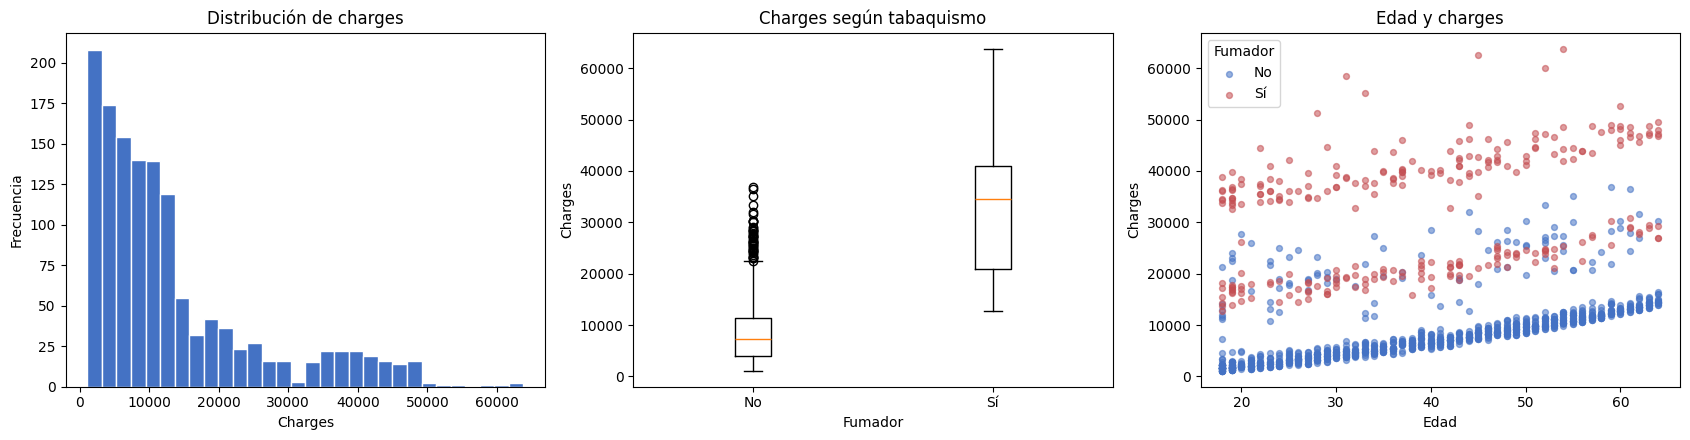

---

#### Interpretación de correlaciones y gráficos

La distribución de `charges` presenta una cola prolongada hacia los valores elevados, lo que confirma su asimetría positiva.

La edad mantiene una correlación positiva de **0,299** con `charges`; el IMC presenta una correlación de **0,198** y el número de hijos una correlación de **0,068**. La edad es, entre estas variables numéricas, la que muestra la mayor asociación lineal con los costes médicos.

El diagrama de cajas muestra que las personas fumadoras presentan costes claramente superiores a las no fumadoras. El diagrama de dispersión también permite observar que los registros de fumadores se concentran generalmente en niveles de coste más elevados para las distintas edades.

Estas observaciones son descriptivas. Las correlaciones no prueban causalidad y la matriz de Pearson no incorpora directamente la información de `smoker` porque se trata de una variable categórica.

---

In [38]:
# ==============================================================
# CORRELACIONES Y VISUALIZACIONES
# ==============================================================
# En esta celda:
# 1. se calculan las correlaciones lineales de Pearson;
# 2. se trasladan al driver sólo los datos necesarios para dibujar;
# 3. se generan tres visualizaciones complementarias;
# 4. se interpretan los resultados en texto.


# --------------------------------------------------------------
# 1. Correlaciones de Pearson
# --------------------------------------------------------------
# Pearson resume la intensidad y dirección de las relaciones
# lineales entre pares de variables numéricas.
#
# Sus valores se encuentran entre:
# - -1: relación lineal negativa perfecta;
# -  0: ausencia de relación lineal;
# -  1: relación lineal positiva perfecta.
#
# Una correlación no demuestra causalidad y tampoco representa
# adecuadamente relaciones no lineales.
correlations = (
    psdf[numeric_columns]
    .corr()
)

print("Matriz de correlaciones de Pearson:")
display(
    correlations.round(3)
)


# --------------------------------------------------------------
# 2. Conversión de los datos necesarios para los gráficos
# --------------------------------------------------------------
# Matplotlib trabaja directamente con pandas tradicional.
# Por ello, las cuatro columnas necesarias se trasladan desde
# pandas API de PySpark hasta la memoria del driver.
#
# PySpark muestra una advertencia porque esta operación no sería
# recomendable con un volumen de datos muy grande.
#
# En este caso la conversión es segura porque sólo se trasladan
# 1.338 filas y cuatro columnas.
#
# Se oculta únicamente el aviso concreto de to_pandas().
# Cualquier otra advertencia continuará siendo visible.
with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message=(
            r"`to_pandas` loads all data into "
            r"the driver's memory.*"
        ),
        category=PandasAPIOnSparkAdviceWarning,
    )

    plot_data = psdf[
        [
            "age",
            "bmi",
            "smoker",
            "charges",
        ]
    ].to_pandas()


# --------------------------------------------------------------
# 3. Preparación de las visualizaciones
# --------------------------------------------------------------
# Se crean tres gráficos:
# 1. distribución de charges;
# 2. comparación de charges según tabaquismo;
# 3. relación entre edad y charges, diferenciando fumadores.
fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 4.5),
)


# --------------------------------------------------------------
# Gráfico 1: distribución de charges
# --------------------------------------------------------------
axes[0].hist(
    plot_data["charges"],
    bins=30,
    color="#4472C4",
    edgecolor="white",
)

axes[0].set(
    title="Distribución de charges",
    xlabel="Charges",
    ylabel="Frecuencia",
)


# --------------------------------------------------------------
# Gráfico 2: comparación según tabaquismo
# --------------------------------------------------------------
groups = [
    plot_data.loc[
        plot_data["smoker"] == value,
        "charges",
    ]
    for value in [
        "no",
        "yes",
    ]
]

axes[1].boxplot(
    groups,
    showfliers=True,
)

# Las etiquetas se establecen por separado para conservar la
# compatibilidad con diferentes versiones de Matplotlib.
axes[1].set_xticks(
    [1, 2]
)

axes[1].set_xticklabels(
    ["No", "Sí"]
)

axes[1].set(
    title="Charges según tabaquismo",
    xlabel="Fumador",
    ylabel="Charges",
)


# --------------------------------------------------------------
# Gráfico 3: relación entre edad y charges
# --------------------------------------------------------------
# Cada grupo se dibuja por separado para que Matplotlib pueda
# construir una leyenda que explique el significado de los colores.
smoker_groups = [
    {
        "value": "no",
        "label": "No",
        "color": "#4472C4",
    },
    {
        "value": "yes",
        "label": "Sí",
        "color": "#C44E52",
    },
]

for group in smoker_groups:
    group_data = plot_data.loc[
        plot_data["smoker"] == group["value"]
    ]

    axes[2].scatter(
        group_data["age"],
        group_data["charges"],
        color=group["color"],
        label=group["label"],
        alpha=0.55,
        s=18,
    )

axes[2].set(
    title="Edad y charges",
    xlabel="Edad",
    ylabel="Charges",
)

axes[2].legend(
    title="Fumador",
)


# --------------------------------------------------------------
# 4. Presentación de los gráficos
# --------------------------------------------------------------
# tight_layout() ajusta los márgenes para evitar que los títulos
# y las etiquetas se superpongan.
fig.tight_layout()
plt.show()


# --------------------------------------------------------------
# 5. Interpretación textual
# --------------------------------------------------------------
# Se extraen dinámicamente las correlaciones con charges para
# incorporarlas al texto sin escribir cifras manualmente.
age_charges_correlation = float(
    correlations.loc[
        "age",
        "charges",
    ]
)

bmi_charges_correlation = float(
    correlations.loc[
        "bmi",
        "charges",
    ]
)

children_charges_correlation = float(
    correlations.loc[
        "children",
        "charges",
    ]
)

visual_interpretation = (
    "La distribución de `charges` presenta una cola prolongada hacia "
    "los valores elevados, lo que confirma su asimetría positiva.\n\n"
    "La edad mantiene una correlación positiva de "
    f"{bold_decimal(age_charges_correlation, 3)} con `charges`; "
    "el IMC presenta una correlación de "
    f"{bold_decimal(bmi_charges_correlation, 3)} y el número de hijos "
    "una correlación de "
    f"{bold_decimal(children_charges_correlation, 3)}. "
    "La edad es, entre estas variables numéricas, la que muestra la "
    "mayor asociación lineal con los costes médicos.\n\n"
    "El diagrama de cajas muestra que las personas fumadoras presentan "
    "costes claramente superiores a las no fumadoras. El diagrama de "
    "dispersión también permite observar que los registros de fumadores "
    "se concentran generalmente en niveles de coste más elevados para "
    "las distintas edades.\n\n"
    "Estas observaciones son descriptivas. Las correlaciones no prueban "
    "causalidad y la matriz de Pearson no incorpora directamente la "
    "información de `smoker` porque se trata de una variable categórica."
)

show_interpretation(
    visual_interpretation,
    title="Interpretación de correlaciones y gráficos",
)

## 1.7. Conclusiones del EDA

- El dataset contiene **1.338 registros y 7 variables**, sin valores nulos en su versión original.
- Existe **un duplicado exacto**, que se eliminará antes de dividir los datos.
- `charges` presenta una distribución claramente asimétrica a la derecha y casos de coste elevado;
  se conservan porque no hay evidencia de que sean errores.
- La condición de **fumador** es la separación descriptiva más marcada: el gasto medio de fumadores
  es varias veces superior al de no fumadores.
- La edad y, en menor medida, el IMC muestran asociación positiva con el coste. La correlación no
  permite afirmar causalidad ni recoge relaciones no lineales o interacciones.
- `sex`, `smoker` y `region` deben codificarse; `age`, `bmi` y `children` son predictores numéricos.
- El modelo lineal será una base interpretable. Su rendimiento puede estar limitado por la asimetría,
  los costes extremos y posibles interacciones como `smoker × bmi`.

---

# Parte 2 (4 puntos): regresión lineal con `pyspark.ml`

## 2.1. Conversión a DataFrame de Spark y limpieza

Se convierte el mismo objeto de pandas API de PySpark mediante `to_spark()`. El índice se conserva temporalmente durante la conversión y se elimina a continuación porque no representa una variable del dataset.

Después se fuerzan los tipos numéricos, se normalizan las variables categóricas, se comprueban los valores `null` y `NaN` y se eliminan las filas incompletas y los duplicados exactos. Los recuentos de la limpieza se calculan dentro de esta misma sección para que no dependa de variables creadas anteriormente durante el EDA.

La variable `charges` no se incluye entre las características porque constituye la etiqueta que se desea predecir.

In [39]:
# ==============================================================
# CONVERSIÓN A DATAFRAME DE SPARK Y LIMPIEZA
# ==============================================================
# En esta celda:
# 1. se convierte el DataFrame de pandas API de PySpark;
# 2. se normalizan los tipos y los textos;
# 3. se comprueban valores null y NaN;
# 4. se eliminan filas incompletas y duplicados;
# 5. se validan los valores numéricos y categóricos;
# 6. se presenta un resumen textual de la limpieza.


from pyspark.sql.functions import (
    avg,
    col,
    count,
    isnan,
    lit,
    lower,
    trim,
    when,
)


# --------------------------------------------------------------
# 1. Conversión a un DataFrame normal de Spark
# --------------------------------------------------------------
# Desde este punto se abandona pandas API de PySpark y se utiliza
# un DataFrame normal de Spark.
#
# El índice se conserva temporalmente como _source_index para hacer
# explícita la conversión. Después se elimina porque no representa
# una variable del dataset y no debe utilizarse como predictor.
df = (
    psdf
    .to_spark(index_col="_source_index")
    .drop("_source_index")
)


# --------------------------------------------------------------
# 2. Normalización de tipos y textos
# --------------------------------------------------------------
# Las variables numéricas se convierten a double, un tipo compatible
# con las transformaciones y modelos de pyspark.ml.
#
# Si apareciese un valor no convertible, Spark lo transformaría
# en null y sería detectado durante la comprobación posterior.
for column in numeric_columns:
    df = df.withColumn(
        column,
        col(column).cast("double"),
    )

# En las variables categóricas:
# - trim() elimina espacios al principio y al final;
# - lower() convierte las etiquetas a minúsculas.
for column in categorical_columns:
    df = df.withColumn(
        column,
        lower(
            trim(
                col(column)
            )
        ),
    )

print("Esquema tras la conversión:")
df.printSchema()


# --------------------------------------------------------------
# 3. Comprobación de valores null y NaN
# --------------------------------------------------------------
# null representa la ausencia general de un valor.
# NaN representa un valor numérico no válido.
#
# lit(1) es necesario porque count() no contabiliza valores null.
null_checks = []

for column in df.columns:
    invalid_condition = col(column).isNull()

    if column in numeric_columns:
        invalid_condition = (
            invalid_condition
            | isnan(column)
        )

    null_checks.append(
        count(
            when(
                invalid_condition,
                lit(1),
            )
        ).alias(column)
    )

print("Valores null o NaN por columna:")
df.select(null_checks).show()


# --------------------------------------------------------------
# 4. Eliminación de filas incompletas
# --------------------------------------------------------------
rows_before = df.count()

# Se eliminan las filas que contengan null o NaN en cualquiera
# de las columnas necesarias para el análisis y el modelado.
df_without_nulls = df.dropna(
    subset=(
        numeric_columns
        + categorical_columns
    )
)

rows_after_nulls = df_without_nulls.count()

null_rows_removed = (
    rows_before
    - rows_after_nulls
)


# --------------------------------------------------------------
# 5. Eliminación de duplicados exactos
# --------------------------------------------------------------
df_clean = (
    df_without_nulls
    .dropDuplicates()
)

rows_after = df_clean.count()

duplicate_count_spark = (
    rows_after_nulls
    - rows_after
)

print(
    "Filas iniciales: "
    f"{format_count(rows_before)}"
)

print(
    "Filas eliminadas por null o NaN: "
    f"{format_count(null_rows_removed)}"
)

print(
    "Duplicados exactos eliminados: "
    f"{format_count(duplicate_count_spark)}"
)

print(
    "Filas disponibles para el modelado: "
    f"{format_count(rows_after)}"
)


# --------------------------------------------------------------
# 6. Validación de los recuentos
# --------------------------------------------------------------
# Se comprueba que:
# - el dataset limpio no esté vacío;
# - el número final de filas coincida con las eliminaciones.
assert rows_after > 0, (
    "La limpieza ha generado un DataFrame vacío."
)

assert rows_after == (
    rows_before
    - null_rows_removed
    - duplicate_count_spark
), (
    "El recuento de filas después de la limpieza "
    "no es coherente."
)


# --------------------------------------------------------------
# 7. Validación de los valores numéricos
# --------------------------------------------------------------
# Se consideran imposibles:
# - edades iguales o inferiores a cero;
# - valores de IMC iguales o inferiores a cero;
# - números de hijos negativos;
# - costes médicos negativos.
invalid_numeric_rows = (
    df_clean
    .filter(
        (col("age") <= 0)
        | (col("bmi") <= 0)
        | (col("children") < 0)
        | (col("charges") < 0)
    )
    .count()
)

assert invalid_numeric_rows == 0, (
    "Hay "
    f"{invalid_numeric_rows} "
    "filas con valores numéricos imposibles."
)

print(
    "Validación numérica superada: no se han encontrado "
    "edades, valores de IMC, hijos o costes imposibles."
)


# --------------------------------------------------------------
# 8. Validación de las variables categóricas
# --------------------------------------------------------------
# Se establece el dominio completo esperado para cada variable.
expected_categories = {
    "sex": {
        "female",
        "male",
    },
    "smoker": {
        "no",
        "yes",
    },
    "region": {
        "northeast",
        "northwest",
        "southeast",
        "southwest",
    },
}

for column, expected in expected_categories.items():

    print(f"\nCategorías de {column}:")

    category_counts = (
        df_clean
        .groupBy(column)
        .count()
        .orderBy(column)
    )

    category_counts.show()

    observed = {
        row[column]
        for row in (
            category_counts
            .select(column)
            .collect()
        )
    }

    # Se comprueban ambas posibles anomalías:
    # - categorías desconocidas;
    # - categorías esperadas que han desaparecido.
    unexpected_categories = (
        observed
        - expected
    )

    missing_categories = (
        expected
        - observed
    )

    assert not unexpected_categories, (
        f"Categorías inesperadas en {column}: "
        f"{sorted(unexpected_categories)}"
    )

    assert not missing_categories, (
        f"Faltan categorías esperadas en {column}: "
        f"{sorted(missing_categories)}"
    )

print(
    "\nValidación categórica superada: todas las etiquetas "
    "pertenecen al dominio esperado y no falta ninguna categoría."
)


# --------------------------------------------------------------
# 9. Interpretación textual de la limpieza
# --------------------------------------------------------------
if null_rows_removed == 0:
    null_summary = (
        "no ha sido necesario eliminar ninguna fila por valores "
        "`null` o `NaN`"
    )
elif null_rows_removed == 1:
    null_summary = (
        "se ha eliminado "
        f"{bold_count(null_rows_removed)} fila por contener valores "
        "`null` o `NaN`"
    )
else:
    null_summary = (
        "se han eliminado "
        f"{bold_count(null_rows_removed)} filas por contener valores "
        "`null` o `NaN`"
    )

if duplicate_count_spark == 0:
    duplicate_summary = (
        "no se han encontrado duplicados exactos"
    )
elif duplicate_count_spark == 1:
    duplicate_summary = (
        "se ha eliminado "
        f"{bold_count(duplicate_count_spark)} duplicado exacto"
    )
else:
    duplicate_summary = (
        "se han eliminado "
        f"{bold_count(duplicate_count_spark)} duplicados exactos"
    )

cleaning_interpretation = (
    "El DataFrame de Spark contenía inicialmente "
    f"{bold_count(rows_before)} registros. Durante la limpieza, "
    f"{null_summary} y {duplicate_summary}.\n\n"
    "El conjunto limpio queda formado por "
    f"{bold_count(rows_after)} registros. Todas las variables "
    "numéricas contienen valores válidos y las variables categóricas "
    "conservan exactamente las etiquetas previstas.\n\n"
    "Este DataFrame limpio será el utilizado para realizar la división "
    "entre entrenamiento y prueba."
)

show_interpretation(
    cleaning_interpretation,
    title="Resultado de la conversión y limpieza",
)

Esquema tras la conversión:
root
 |-- age: double (nullable = true)
 |-- sex: string (nullable = true)
 |-- bmi: double (nullable = true)
 |-- children: double (nullable = true)
 |-- smoker: string (nullable = true)
 |-- region: string (nullable = true)
 |-- charges: double (nullable = true)

Valores null o NaN por columna:
+---+---+---+--------+------+------+-------+
|age|sex|bmi|children|smoker|region|charges|
+---+---+---+--------+------+------+-------+
|  0|  0|  0|       0|     0|     0|      0|
+---+---+---+--------+------+------+-------+

Filas iniciales: 1.338
Filas eliminadas por null o NaN: 0
Duplicados exactos eliminados: 1
Filas disponibles para el modelado: 1.337
Validación numérica superada: no se han encontrado edades, valores de IMC, hijos o costes imposibles.

Categorías de sex:
+------+-----+
|   sex|count|
+------+-----+
|female|  662|
|  male|  675|
+------+-----+


Categorías de smoker:
+------+-----+
|smoker|count|
+------+-----+
|    no| 1063|
|   yes|  274|
+---

---

#### Resultado de la conversión y limpieza

El DataFrame de Spark contenía inicialmente **1.338** registros. Durante la limpieza, no ha sido necesario eliminar ninguna fila por valores `null` o `NaN` y se ha eliminado **1** duplicado exacto.

El conjunto limpio queda formado por **1.337** registros. Todas las variables numéricas contienen valores válidos y las variables categóricas conservan exactamente las etiquetas previstas.

Este DataFrame limpio será el utilizado para realizar la división entre entrenamiento y prueba.

---

## 2.2. División entrenamiento/prueba

Se reserva aproximadamente un 20 % para evaluar datos no usados en el ajuste. La semilla fija hace
reproducible la división. Se cachean ambos subconjuntos porque se reutilizarán varias veces.

In [40]:
# ==============================================================
# DIVISIÓN ENTRE ENTRENAMIENTO Y PRUEBA
# ==============================================================
# En esta celda:
# 1. se divide el dataset limpio;
# 2. se utiliza una semilla para obtener reproducibilidad;
# 3. se almacenan temporalmente los subconjuntos en memoria;
# 4. se comprueba que no se hayan perdido registros;
# 5. se interpreta el resultado de la división.


# --------------------------------------------------------------
# 1. División reproducible
# --------------------------------------------------------------
# randomSplit() asigna aleatoriamente cada registro a uno de los
# dos subconjuntos de acuerdo con los pesos indicados:
# - 0.8 para entrenamiento;
# - 0.2 para prueba.
#
# Los pesos expresan proporciones aproximadas. No garantizan que
# el resultado contenga exactamente un 80 % y un 20 %.
#
# La semilla SEED hace repetible la asignación mientras se mantengan
# los mismos datos, particiones y entorno de ejecución.
train_df, test_df = df_clean.randomSplit(
    weights=[
        0.8,
        0.2,
    ],
    seed=SEED,
)


# --------------------------------------------------------------
# 2. Almacenamiento temporal en memoria
# --------------------------------------------------------------
# Ambos subconjuntos se reutilizarán durante el ajuste, la evaluación
# y el cálculo del modelo base.
#
# cache() evita recalcular toda la limpieza cada vez que se realiza
# una nueva acción sobre ellos.
train_df = train_df.cache()
test_df = test_df.cache()


# --------------------------------------------------------------
# 3. Materialización y recuento
# --------------------------------------------------------------
# count() ejecuta la división y materializa la caché.
train_count = train_df.count()
test_count = test_df.count()

train_percentage = (
    train_count
    / rows_after
    * 100
)

test_percentage = (
    test_count
    / rows_after
    * 100
)


# --------------------------------------------------------------
# 4. Validaciones de la división
# --------------------------------------------------------------
# Ninguno de los subconjuntos debe quedar vacío.
assert train_count > 0, (
    "El conjunto de entrenamiento está vacío."
)

assert test_count > 0, (
    "El conjunto de prueba está vacío."
)

# La suma debe coincidir con el número de registros disponibles
# después de la limpieza.
assert train_count + test_count == rows_after, (
    "Se han perdido o duplicado filas durante la división."
)

# Los porcentajes deben sumar aproximadamente el 100 %.
assert abs(
    train_percentage
    + test_percentage
    - 100
) < 0.001, (
    "Los porcentajes de entrenamiento y prueba no suman el 100 %."
)


# --------------------------------------------------------------
# 5. Presentación de los resultados
# --------------------------------------------------------------
print(
    "Entrenamiento: "
    f"{format_count(train_count)} filas "
    f"({format_percentage(train_percentage)} %)"
)

print(
    "Prueba:        "
    f"{format_count(test_count)} filas "
    f"({format_percentage(test_percentage)} %)"
)


# --------------------------------------------------------------
# 6. Interpretación textual
# --------------------------------------------------------------
split_interpretation = (
    "El conjunto limpio, formado por "
    f"{bold_count(rows_after)} registros, se ha dividido en "
    f"{bold_count(train_count)} observaciones de entrenamiento "
    f"({bold_percentage(train_percentage)}) y "
    f"{bold_count(test_count)} observaciones de prueba "
    f"({bold_percentage(test_percentage)}).\n\n"
    "El conjunto de entrenamiento se utilizará para aprender las "
    "transformaciones y ajustar la regresión lineal. El conjunto de "
    "prueba permanecerá separado durante el entrenamiento y se empleará "
    "únicamente para evaluar la capacidad del modelo sobre observaciones "
    "no utilizadas durante el ajuste.\n\n"
    "La comprobación de los recuentos confirma que no se ha perdido ni "
    "duplicado ninguna fila durante la división."
)

show_interpretation(
    split_interpretation,
    title="División entre entrenamiento y prueba",
)

NameError: name 'format_percentage' is not defined

## 2.3. Pipeline de transformación y regresión

Flujo de cada observación:

1. `StringIndexer` convierte las categorías en índices.
2. `OneHotEncoder` evita imponer un orden artificial entre categorías.
3. `VectorAssembler` reúne las variables numéricas.
4. `StandardScaler` centra y escala sólo los predictores numéricos.
5. Un segundo `VectorAssembler` crea la columna `features`.
6. `LinearRegression` aprende a predecir `charges`.

En `StringIndexer` y `OneHotEncoder` se utiliza `handleInvalid="keep"` para que el `Pipeline` pueda transformar categorías que no hubieran aparecido durante el entrenamiento. Esas categorías se asignan a una categoría adicional denominada internamente `__unknown`. Esta decisión hace el `Pipeline` más robusto para datos futuros y también evita errores si una categoría aparece en `test_df`, pero no en `train_df`.

En los dos `VectorAssembler` se utiliza `handleInvalid="error"` porque, en el caso de los predictores numéricos y del vector final, la presencia de valores inválidos debe considerarse un problema de calidad de los datos.

Como todas las transformaciones forman parte del `Pipeline`, los índices categóricos, la codificación y los parámetros de escalado se aprenden exclusivamente a partir de `train_df`, evitando fuga de información.

In [ ]:
# ==============================================================
# PIPELINE DE TRANSFORMACIÓN Y REGRESIÓN LINEAL
# ==============================================================
# En esta celda:
# 1. se definen las transformaciones categóricas;
# 2. se ensamblan y escalan las variables numéricas;
# 3. se construye el vector final de características;
# 4. se define la regresión lineal;
# 5. se ajusta todo el Pipeline utilizando solamente train_df;
# 6. se generan las predicciones para test_df.


from pyspark.ml import Pipeline

from pyspark.ml.feature import (
    OneHotEncoder,
    StandardScaler,
    StringIndexer,
    VectorAssembler,
)

from pyspark.ml.regression import LinearRegression


# --------------------------------------------------------------
# 1. Definición de las columnas predictoras
# --------------------------------------------------------------
# charges no aparece en numeric_features porque constituye
# la variable objetivo que el modelo debe predecir.
numeric_features = [
    "age",
    "bmi",
    "children",
]

# Se generan una sola vez los nombres de las columnas que crearán
# StringIndexer y OneHotEncoder.
indexed_columns = [
    f"{column}_index"
    for column in categorical_columns
]

encoded_columns = [
    f"{column}_ohe"
    for column in categorical_columns
]


# --------------------------------------------------------------
# 2. Conversión de categorías a índices
# --------------------------------------------------------------
# StringIndexer asigna un índice numérico a cada categoría.
#
# Los indexadores se ajustarán exclusivamente con train_df porque
# forman parte del Pipeline. Así se evita que el conjunto de prueba
# aporte información durante el entrenamiento.
#
# handleInvalid="keep" reserva una categoría adicional para valores
# que no hubieran aparecido durante el ajuste. Esto permite procesar
# categorías nuevas sin detener automáticamente el Pipeline.
indexers = [
    StringIndexer(
        inputCol=column,
        outputCol=f"{column}_index",
        handleInvalid="keep",
    )
    for column in categorical_columns
]


# --------------------------------------------------------------
# 3. Codificación one-hot
# --------------------------------------------------------------
# OneHotEncoder transforma los índices categóricos en vectores
# binarios y evita imponer una relación ordinal entre categorías.
#
# handleInvalid="keep" conserva la categoría adicional destinada
# a valores desconocidos.
#
# dropLast=True elimina la última posición de la codificación para
# reducir columnas redundantes. Al utilizar keep, la posición omitida
# puede corresponder a la categoría técnica reservada para valores
# desconocidos y no necesariamente a una categoría real.
encoder = OneHotEncoder(
    inputCols=indexed_columns,
    outputCols=encoded_columns,
    handleInvalid="keep",
    dropLast=True,
)


# --------------------------------------------------------------
# 4. Ensamblado de las variables numéricas
# --------------------------------------------------------------
# VectorAssembler agrupa age, bmi y children en un único vector.
#
# handleInvalid="error" detiene el proceso si encuentra un valor
# numérico inválido. La limpieza anterior debería impedirlo.
numeric_assembler = VectorAssembler(
    inputCols=numeric_features,
    outputCol="numeric_features",
    handleInvalid="error",
)


# --------------------------------------------------------------
# 5. Estandarización de las variables numéricas
# --------------------------------------------------------------
# StandardScaler aprende la media y la desviación típica solamente
# a partir de train_df.
#
# withMean=True centra cada variable alrededor de cero.
# withStd=True divide cada variable por su desviación típica.
#
# Esto evita que las diferencias de escala entre edad, IMC e hijos
# condicionen la comparación de sus coeficientes.
scaler = StandardScaler(
    inputCol="numeric_features",
    outputCol="scaled_numeric_features",
    withMean=True,
    withStd=True,
)


# --------------------------------------------------------------
# 6. Construcción del vector final de características
# --------------------------------------------------------------
# Se combinan:
# - las variables numéricas estandarizadas;
# - los vectores one-hot de las variables categóricas.
#
# El resultado se guarda en features, nombre esperado por el modelo.
final_assembler = VectorAssembler(
    inputCols=(
        ["scaled_numeric_features"]
        + encoded_columns
    ),
    outputCol="features",
    handleInvalid="error",
)


# --------------------------------------------------------------
# 7. Definición de la regresión lineal
# --------------------------------------------------------------
# El modelo aprende a predecir charges utilizando features.
#
# regParam=0.0 y elasticNetParam=0.0 indican que no se aplica
# regularización. Se obtiene una regresión lineal ordinaria.
linear_regression = LinearRegression(
    featuresCol="features",
    labelCol="charges",
    predictionCol="prediction",
    maxIter=100,
    regParam=0.0,
    elasticNetParam=0.0,
)


# --------------------------------------------------------------
# 8. Construcción del Pipeline
# --------------------------------------------------------------
# Las etapas se almacenan en una lista explícita para mostrar
# claramente el orden en que se aplicarán.
pipeline_stages = (
    indexers
    + [
        encoder,
        numeric_assembler,
        scaler,
        final_assembler,
        linear_regression,
    ]
)

pipeline = Pipeline(
    stages=pipeline_stages
)


# --------------------------------------------------------------
# 9. Ajuste del Pipeline
# --------------------------------------------------------------
# fit() aprende exclusivamente a partir del conjunto de entrenamiento:
# - las categorías de StringIndexer;
# - los tamaños de OneHotEncoder;
# - la media y desviación típica de StandardScaler;
# - los coeficientes de LinearRegression.
pipeline_model = pipeline.fit(
    train_df
)


# --------------------------------------------------------------
# 10. Predicciones sobre el conjunto de prueba
# --------------------------------------------------------------
# transform() aplica al conjunto de prueba las transformaciones
# aprendidas durante el entrenamiento.
#
# Las predicciones se almacenan en caché porque se reutilizarán
# para calcular métricas, coeficientes y residuos.
predictions = (
    pipeline_model
    .transform(test_df)
    .cache()
)

# count() materializa la caché y comprueba que se haya generado
# exactamente una predicción por cada fila del conjunto de prueba.
prediction_count = predictions.count()

assert prediction_count == test_count, (
    "El número de predicciones no coincide con "
    "el número de filas de prueba."
)

# El modelo ajustado debe contener tantas etapas como las definidas.
assert len(pipeline_model.stages) == len(pipeline_stages), (
    "El número de etapas ajustadas no coincide con "
    "la definición del Pipeline."
)

print(
    "Pipeline ajustado correctamente."
)

print(
    "Etapas del Pipeline: "
    f"{len(pipeline_model.stages)}"
)

print(
    "Predicciones generadas: "
    f"{format_count(prediction_count)}"
)


# --------------------------------------------------------------
# 11. Interpretación del proceso
# --------------------------------------------------------------
pipeline_interpretation = (
    "El `Pipeline` contiene "
    f"{bold_count(len(pipeline_model.stages))} etapas y se ha ajustado "
    "exclusivamente con las "
    f"{bold_count(train_count)} observaciones del conjunto de "
    "entrenamiento.\n\n"
    "Los índices categóricos, la codificación, los parámetros de "
    "escalado y los coeficientes de la regresión se han aprendido sin "
    "utilizar el conjunto de prueba, evitando fuga de información.\n\n"
    "Después del ajuste se han generado "
    f"{bold_count(prediction_count)} predicciones, exactamente una por "
    "cada registro de `test_df`."
)

show_interpretation(
    pipeline_interpretation,
    title="Construcción y ajuste del Pipeline",
)

## 2.4. Predicciones y métricas

- **RMSE:** penaliza especialmente los errores grandes y conserva las unidades monetarias.
- **MAE:** error absoluto medio, también en unidades monetarias y más resistente a casos extremos.
- **R²:** proporción de variabilidad explicada respecto a predecir una constante.

Además se compara el modelo con una referencia ingenua que siempre predice la media de `charges`
del conjunto de entrenamiento. Una regresión útil debería reducir claramente RMSE y MAE frente a ella.

In [ ]:
from pyspark.ml.evaluation import RegressionEvaluator

# Prueba de humo: debe existir exactamente una predicción válida por fila de test.
prediction_count = predictions.count()
invalid_predictions = predictions.filter(
    col("prediction").isNull() | isnan("prediction")
).count()
assert prediction_count == test_count, "El número de predicciones no coincide con test."
assert invalid_predictions == 0, "El modelo ha producido predicciones nulas o NaN."
print(f"Prueba de humo superada: {prediction_count} predicciones válidas.")

predictions.select(
    "age", "sex", "bmi", "children", "smoker", "region", "charges", "prediction"
).show(10, truncate=False)

# Todas las métricas se calculan exclusivamente con el conjunto de prueba.
metrics = {}
for metric_name in ["rmse", "mae", "r2"]:
    evaluator = RegressionEvaluator(
        labelCol="charges",
        predictionCol="prediction",
        metricName=metric_name,
    )
    metrics[metric_name] = evaluator.evaluate(predictions)

print(f"RMSE: {metrics['rmse']:,.2f}")
print(f"MAE:  {metrics['mae']:,.2f}")
print(f"R²:   {metrics['r2']:.4f}")

train_mean = train_df.select(avg("charges").alias("mean_charge")).first()["mean_charge"]
baseline_predictions = predictions.withColumn("baseline_prediction", lit(train_mean))
baseline_metrics = {}
for metric_name in ["rmse", "mae"]:
    evaluator = RegressionEvaluator(
        labelCol="charges",
        predictionCol="baseline_prediction",
        metricName=metric_name,
    )
    baseline_metrics[metric_name] = evaluator.evaluate(baseline_predictions)

print("\nModelo base (media de train):")
print(f"RMSE base: {baseline_metrics['rmse']:,.2f}")
print(f"MAE base:  {baseline_metrics['mae']:,.2f}")
rmse_reduction = 1 - metrics["rmse"] / baseline_metrics["rmse"]
print(f"Reducción de RMSE: {rmse_reduction:.1%}")

# Interpretación ligada a los valores realmente calculados, no a cifras escritas a mano.
print("\nInterpretación:")
print(f"- La regresión reduce el RMSE un {rmse_reduction:.1%} frente a predecir siempre la media.")
if metrics["r2"] >= 0.75:
    print("- El modelo explica una proporción alta de la variabilidad de charges en test.")
elif metrics["r2"] >= 0.50:
    print("- El modelo explica una proporción moderada de la variabilidad de charges en test.")
else:
    print("- La capacidad explicativa es limitada; convendría revisar supuestos y alternativas.")

## 2.5. Coeficientes y análisis de residuos

Los coeficientes numéricos corresponden a variables estandarizadas: expresan el cambio esperado en `charges` al aumentar una desviación típica, manteniendo constantes las demás características.

Debido al uso de `handleInvalid="keep"`, la codificación reserva una categoría adicional para valores desconocidos. Por ello, no necesariamente se omite una categoría real como referencia y los coeficientes categóricos individuales no deben interpretarse directamente como diferencias respecto a una categoría real omitida. Resulta más apropiado comparar las diferencias entre los coeficientes de las categorías conocidas.

Por ejemplo, la diferencia entre los coeficientes de `smoker_ohe_yes` y `smoker_ohe_no` representa la diferencia estimada entre fumadores y no fumadores, manteniendo constantes las demás características.

Los coeficientes describen asociaciones dentro del modelo y no deben interpretarse como efectos causales.

In [ ]:
# La regresión es la última etapa del Pipeline ya ajustado.
lr_model = pipeline_model.stages[-1]
print(f"Intercepto: {lr_model.intercept:,.2f}")

# Spark conserva en 'features' metadatos con los nombres tras el ensamblado.
feature_metadata = predictions.schema["features"].metadata.get("ml_attr", {}).get("attrs", {})
attributes = [item for group in feature_metadata.values() for item in group]
attributes = sorted(attributes, key=lambda item: item["idx"])
feature_names = [item.get("name", f"feature_{item['idx']}") for item in attributes]
if len(feature_names) != len(lr_model.coefficients):
    feature_names = [f"feature_{i}" for i in range(len(lr_model.coefficients))]

coefficient_table = pd.DataFrame(
    {"variable_transformada": feature_names, "coeficiente": list(lr_model.coefficients)}
)
coefficient_table["valor_absoluto"] = coefficient_table["coeficiente"].abs()
display(coefficient_table.sort_values("valor_absoluto", ascending=False).drop(columns="valor_absoluto"))

In [ ]:
from pyspark.sql.functions import mean, stddev

# Residuo positivo: el coste real fue superior al estimado por el modelo.
residual_predictions = predictions.withColumn("residual", col("charges") - col("prediction"))
print("Resumen de residuos en test:")
residual_predictions.select(
    mean("residual").alias("media_residuo"),
    stddev("residual").alias("desviacion_residuo"),
).show()

test_plot = residual_predictions.select("charges", "prediction", "residual").toPandas()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(test_plot["charges"], test_plot["prediction"], alpha=0.6, s=22)
line_min = min(test_plot["charges"].min(), test_plot["prediction"].min())
line_max = max(test_plot["charges"].max(), test_plot["prediction"].max())
axes[0].plot([line_min, line_max], [line_min, line_max], "r--", linewidth=1)
axes[0].set(title="Real frente a predicción", xlabel="Charges reales", ylabel="Predicción")

axes[1].scatter(test_plot["prediction"], test_plot["residual"], alpha=0.6, s=22)
axes[1].axhline(0, color="red", linestyle="--", linewidth=1)
axes[1].set(title="Residuos frente a predicción", xlabel="Predicción", ylabel="Real - predicción")

fig.tight_layout()
plt.show()

## Conclusión final y comprobación del enunciado

Se ha completado el flujo solicitado con separación estricta entre APIs:

- El EDA se ha realizado sobre un `pyspark.pandas.DataFrame`.
- Los datos se han convertido después a un DataFrame normal de Spark.
- La preparación y la regresión se han implementado con `pyspark.ml` dentro de un `Pipeline`.
- La evaluación se hace sobre un conjunto de prueba independiente y se compara con una referencia base.

### Lista de comprobación para la corrección

- ✅ EDA realizado con `pyspark.pandas`.
- ✅ Conversión posterior a un DataFrame normal de Spark.
- ✅ Variables categóricas transformadas con `StringIndexer` y `OneHotEncoder`.
- ✅ Variables numéricas reunidas con `VectorAssembler` y escaladas con `StandardScaler`.
- ✅ Regresión lineal entrenada exclusivamente con el conjunto de entrenamiento.
- ✅ Evaluación independiente mediante RMSE, MAE y R², con comparación frente a un modelo base.
- ✅ Validaciones de datos, división y predicciones ejecutadas como pruebas de humo.

En este problema, la regresión lineal suele mejorar claramente la predicción constante gracias sobre
todo a la información de tabaquismo, edad e IMC. Sin embargo, los residuos y los costes extremos
muestran que una relación puramente aditiva y lineal no captura toda la complejidad. Como extensión
futura sería razonable comparar una transformación `log1p(charges)`, añadir interacciones justificadas
o evaluar modelos no lineales, siempre manteniendo el conjunto de prueba aislado.

In [ ]:
# Liberación opcional de recursos al terminar la práctica.
predictions.unpersist()
train_df.unpersist()
test_df.unpersist()
spark.stop()
print("Sesión de Spark detenida.")